In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import numpy as np

In [4]:
overview = pd.read_csv('bronko_results/bronko_overview.tsv', delimiter='\t')

In [5]:
overview

,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers
0,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,3,55,0.9985,51340.7970,65875,1227764,1723092
1,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,51,0.9982,36234.4225,58599,978659,902210
2,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,3,54,0.9633,1776.0161,36765,91114,44914
3,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,6,42,0.9980,19246.6070,52680,844813,1028381
4,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,7,52,0.9986,24382.5542,54228,1039976,886576
...,...,...,...,...,...,...,...,...,...
934,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,7,58,0.9981,50357.9147,65504,1142225,1135198
935,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,3,60,0.9902,5454.3177,39020,250799,121523
936,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,3,48,0.9975,21577.9641,47294,664489,457265
937,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,17,63,0.9970,12225.7005,43293,523840,374020


In [6]:
overview['selected_genome'].value_counts()

selected_genome
PX422652.1    301
ON249995.1    217
MZ470855.1    187
OZ286419.1     39
OL672836.1     39
OP661948.1     22
MW423686.2     20
OM354922.1     19
PX447353.1     19
PX131797.1     16
PX432547.1     13
ON252856.1     13
OP167709.1      9
PV068298.1      8
PX432549.1      5
OQ329372.1      4
PV014231.1      2
ON939308.1      2
OQ167064.1      2
PX105998.1      1
OM958567.1      1
Name: count, dtype: int64

<Axes: >

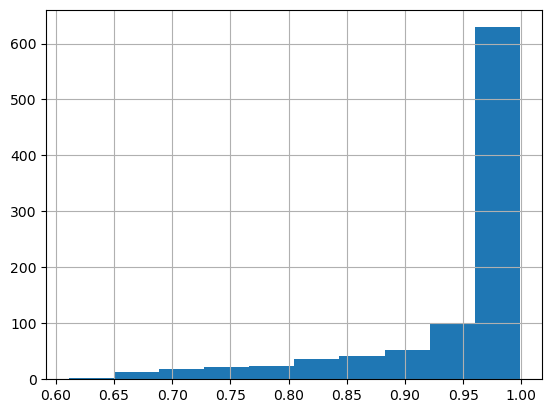

In [7]:
overview['breadth_coverage'].hist()

<Axes: >

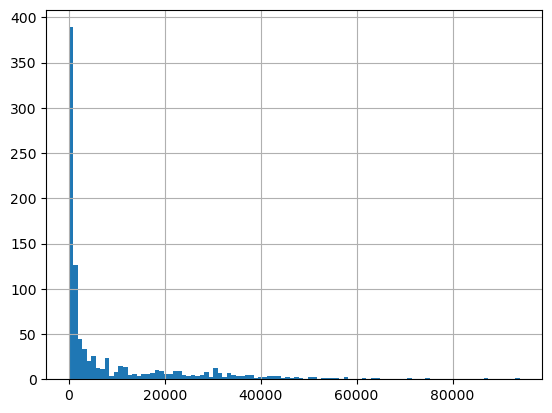

In [8]:
overview['depth_coverage'].hist(bins=100)

In [9]:
high_quality = overview[(overview['depth_coverage'] > 5000) & (overview['breadth_coverage'] > 0.9)]
high_quality

,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers
0,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,3,55,0.9985,51340.7970,65875,1227764,1723092
1,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,51,0.9982,36234.4225,58599,978659,902210
3,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,6,42,0.9980,19246.6070,52680,844813,1028381
4,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,7,52,0.9986,24382.5542,54228,1039976,886576
6,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,46,0.9984,18813.6423,52414,875187,1281283
...,...,...,...,...,...,...,...,...,...
934,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,7,58,0.9981,50357.9147,65504,1142225,1135198
935,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,3,60,0.9902,5454.3177,39020,250799,121523
936,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,3,48,0.9975,21577.9641,47294,664489,457265
937,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,17,63,0.9970,12225.7005,43293,523840,374020


In [10]:
high_quality['selected_genome'].value_counts()

selected_genome
PX422652.1    115
ON249995.1    103
OZ286419.1     18
OM354922.1     14
OP661948.1      9
OL672836.1      8
ON252856.1      7
MZ470855.1      7
PX131797.1      7
PX447353.1      5
OP167709.1      4
PV068298.1      4
MW423686.2      4
OQ329372.1      3
PV014231.1      2
OQ167064.1      2
PX105998.1      1
PX432549.1      1
OM958567.1      1
Name: count, dtype: int64

In [11]:
meta = pd.read_excel('mmc3 (1).xlsx')
files = glob.glob("ena_*.tsv")
accs = pd.concat((pd.read_csv(f, delimiter='\t') for f in files), ignore_index=True)
accs["COG-ID"] = accs["description"].str.extract(r"COG-UK/([^/]+)/")
merged = meta.merge(accs, on='COG-ID', how='inner')

In [12]:
merged

,person id,COG-ID,sequence collection date,accession,description
0,p1,OXON-F6DBE3,2021-02-12,ERR5474868,unspecified sequencing: COG-UK/OXON-F6DBE3/OXO...
1,p1,OXON-F8087A,2021-04-03,ERR5776176,unspecified sequencing: COG-UK/OXON-F8087A/OXO...
2,p1,PHEC-YYBDXFY,2021-08-22,ERR6836828,NextSeq 550 sequencing: COG-UK/PHEC-YYBDXFY/PH...
3,p2,MILK-DAC8E3,2020-12-28,ERR5244621,Illumina NovaSeq 6000 sequencing: Illumina Nov...
4,p2,OXON-F87E80,2021-06-15,ERR6304363,unspecified sequencing: COG-UK/OXON-F87E80/OXO...
...,...,...,...,...,...
934,p574,QEUH-326FE473,2023-03-06,ERR11026144,Illumina NovaSeq 6000 sequencing: Illumina Nov...
935,p575,QEUH-326B6C60,2023-01-29,ERR10864250,Illumina NovaSeq 6000 sequencing: Illumina Nov...
936,p575,QEUH-326EF202,2023-02-26,ERR13623125,Illumina NovaSeq 6000 sequencing: Illumina Nov...
937,p576,QEUH-326BFE8F,2023-01-31,ERR10888149,Illumina NovaSeq 6000 sequencing: Illumina Nov...


In [13]:
high_quality['accession'] = high_quality['filename'].str.extract(r"([^/]+)(?=\_1.fastq)")
high_quality

/tmp/ipykernel_1485469/2737700841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_quality['accession'] = high_quality['filename'].str.extract(r"([^/]+)(?=\_1.fastq)")


,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers,accession
0,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,3,55,0.9985,51340.7970,65875,1227764,1723092,ERR10004639
1,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,51,0.9982,36234.4225,58599,978659,902210,ERR10005437
3,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,6,42,0.9980,19246.6070,52680,844813,1028381,ERR10020827
4,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,7,52,0.9986,24382.5542,54228,1039976,886576,ERR10021174
6,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,46,0.9984,18813.6423,52414,875187,1281283,ERR10022928
...,...,...,...,...,...,...,...,...,...,...
934,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,7,58,0.9981,50357.9147,65504,1142225,1135198,ERR9989358
935,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,3,60,0.9902,5454.3177,39020,250799,121523,ERR9989476
936,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,3,48,0.9975,21577.9641,47294,664489,457265,ERR9989534
937,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,17,63,0.9970,12225.7005,43293,523840,374020,ERR9989618


In [14]:
high_quality_with_meta = high_quality.merge(merged, on="accession", how="left")
high_quality_with_meta

,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers,accession,person id,COG-ID,sequence collection date,description
0,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,3,55,0.9985,51340.7970,65875,1227764,1723092,ERR10004639,p461,QEUH-3EF57D5,2022-07-18,Illumina NovaSeq 6000 sequencing: Illumina Nov...
1,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,51,0.9982,36234.4225,58599,978659,902210,ERR10005437,p462,QEUH-3EF7AF8,2022-07-15,Illumina NovaSeq 6000 sequencing: Illumina Nov...
2,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,6,42,0.9980,19246.6070,52680,844813,1028381,ERR10020827,p463,QEUH-3EFABC5,2022-07-16,Illumina NovaSeq 6000 sequencing: Illumina Nov...
3,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,7,52,0.9986,24382.5542,54228,1039976,886576,ERR10021174,p402,QEUH-3EFD3E8,2022-07-20,Illumina NovaSeq 6000 sequencing: Illumina Nov...
4,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,46,0.9984,18813.6423,52414,875187,1281283,ERR10022928,p465,QEUH-3F08AF3,2022-07-12,Illumina NovaSeq 6000 sequencing: Illumina Nov...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,7,58,0.9981,50357.9147,65504,1142225,1135198,ERR9989358,p458,QEUH-3EEE65A,2022-07-13,Illumina NovaSeq 6000 sequencing: Illumina Nov...
311,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,3,60,0.9902,5454.3177,39020,250799,121523,ERR9989476,p401,QEUH-3EED679,2022-07-08,Illumina NovaSeq 6000 sequencing: Illumina Nov...
312,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,3,48,0.9975,21577.9641,47294,664489,457265,ERR9989534,p557,QEUH-3EEDA5F,2022-07-15,Illumina NovaSeq 6000 sequencing: Illumina Nov...
313,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,17,63,0.9970,12225.7005,43293,523840,374020,ERR9989618,p288,QEUH-3EEE7DF,2022-07-12,Illumina NovaSeq 6000 sequencing: Illumina Nov...


In [15]:
high_quality_with_meta['person id'].value_counts()

person id
p288    6
p392    5
p356    3
p493    3
p350    2
       ..
p418    1
p2      1
p6      1
p9      1
p543    1
Name: count, Length: 268, dtype: int64

In [16]:
final_data = high_quality_with_meta[high_quality_with_meta["person id"].map(high_quality_with_meta["person id"].value_counts()) > 1]
print("Number of individuals:", len(final_data['person id'].value_counts()))
print("Number of samples:", len(final_data['person id']))


Number of individuals: 38
Number of samples: 85


In [17]:
len(final_data)

85

In [18]:
final_data['selected_genome'].value_counts()

selected_genome
PX422652.1    31
ON249995.1    27
OZ286419.1     6
OM354922.1     3
PX131797.1     3
OQ329372.1     3
OP661948.1     3
PX447353.1     2
OQ167064.1     2
OP167709.1     2
OL672836.1     2
PV014231.1     1
Name: count, dtype: int64

Text(0, 0.5, 'Number of Minor Variants')

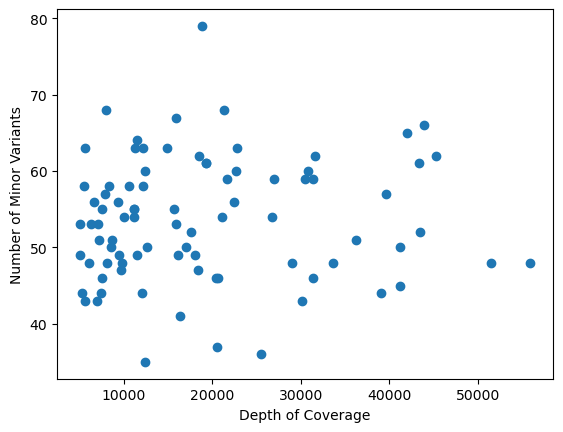

In [19]:
plt.scatter(final_data['depth_coverage'], final_data['num_minor_variants'])
plt.xlabel('Depth of Coverage')
plt.ylabel('Number of Minor Variants')

Text(0, 0.5, 'Number of Minor Variants')

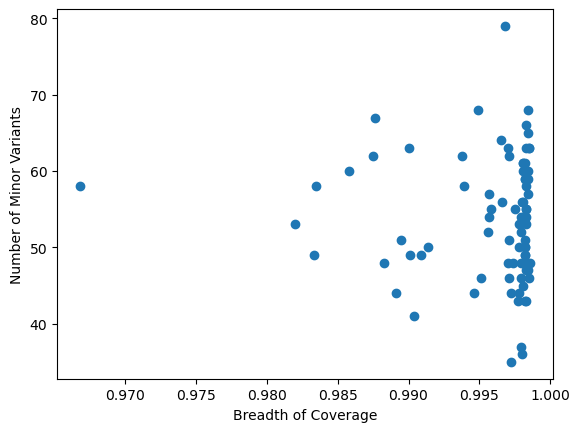

In [20]:
plt.scatter(final_data['breadth_coverage'], final_data['num_minor_variants'])
plt.xlabel('Breadth of Coverage')
plt.ylabel('Number of Minor Variants')

Text(0, 0.5, 'Number of Major Variants')

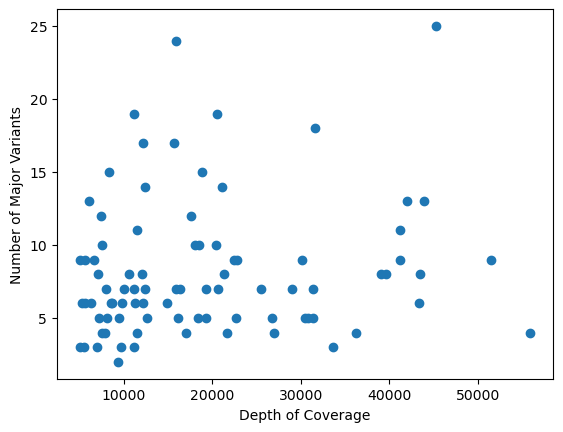

In [21]:
plt.scatter(final_data['depth_coverage'], final_data['num_major_variants'])
plt.xlabel('Depth of Coverage')
plt.ylabel('Number of Major Variants')

Text(0, 0.5, 'Number of Major Variants')

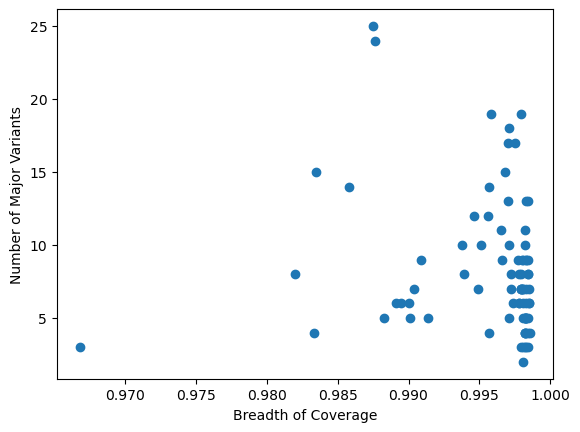

In [22]:
plt.scatter(final_data['breadth_coverage'], final_data['num_major_variants'])
plt.xlabel('Breadth of Coverage')
plt.ylabel('Number of Major Variants')

Text(0, 0.5, 'Number of 1-edit distance kmers')

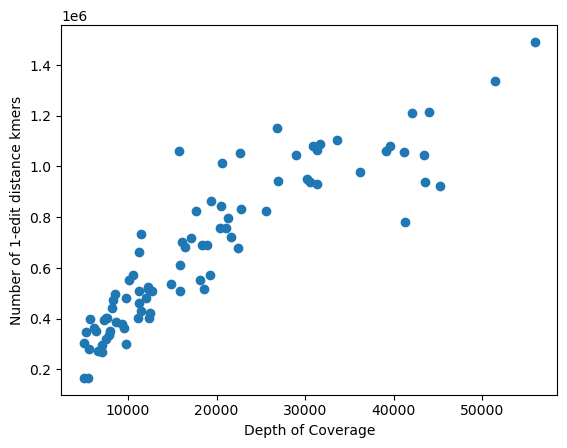

In [23]:
plt.scatter(final_data['depth_coverage'], final_data['num_variant_kmers'])
plt.xlabel('Depth of Coverage')
plt.ylabel('Number of 1-edit distance kmers')

In [24]:
person_counts = final_data.groupby("person id")["selected_genome"].unique()
person_counts

person id
p192                [OL672836.1]
p286    [PX422652.1, OM354922.1]
p288    [OM354922.1, PX422652.1]
p306                [PX422652.1]
p320                [PX422652.1]
p321                [PX422652.1]
p339                [PX422652.1]
p342                [PX422652.1]
p343                [PX422652.1]
p350                [PX422652.1]
p356    [OM354922.1, PX422652.1]
p366                [PX422652.1]
p392                [PX422652.1]
p407                [PX422652.1]
p416    [OP661948.1, PX131797.1]
p421                [OP661948.1]
p423                [PX131797.1]
p427                [ON249995.1]
p431                [ON249995.1]
p444                [ON249995.1]
p448                [ON249995.1]
p462                [ON249995.1]
p467                [ON249995.1]
p469                [ON249995.1]
p480                [ON249995.1]
p488                [ON249995.1]
p493                [ON249995.1]
p497                [ON249995.1]
p498                [ON249995.1]
p523                [ON249995.1]


In [25]:
len(person_counts)

38

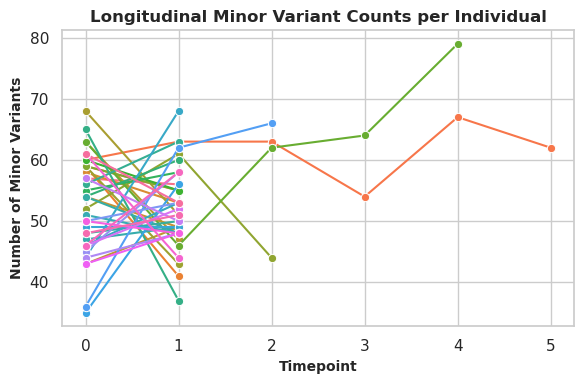

In [27]:
# Sort by person and date, then assign timepoint indices per person
df = final_data.sort_values(["person id", "sequence collection date"])
df["timepoint"] = df.groupby("person id").cumcount()

# Plot: x = num_minor_variants, y = timepoint, line per person
plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df,
    x="timepoint",
    y="num_minor_variants",
    hue="person id",
    marker="o",
    legend=False  # hide if too many individuals
)

plt.xlabel("Timepoint", fontweight='bold', fontsize=10)
plt.ylabel("Number of Minor Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Minor Variant Counts per Individual", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



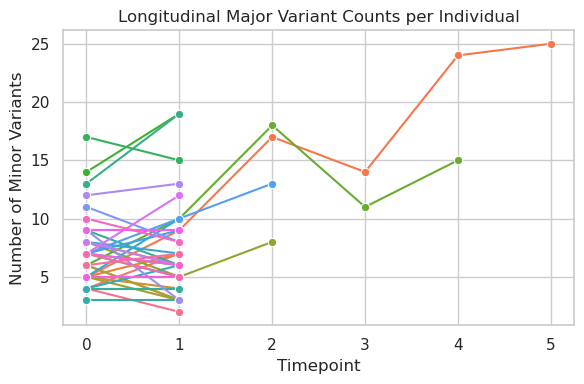

In [28]:
# Sort by person and date, then assign timepoint indices per person
df = final_data.sort_values(["person id", "sequence collection date"])
df["timepoint"] = df.groupby("person id").cumcount()

# Plot: x = num_minor_variants, y = timepoint, line per person
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df,
    x="timepoint",
    y="num_major_variants",
    hue="person id",
    marker="o",
    legend=False  # hide if too many individuals
)

plt.xlabel("Timepoint")
plt.ylabel("Number of Minor Variants")
plt.title("Longitudinal Major Variant Counts per Individual")
plt.tight_layout()
plt.show()

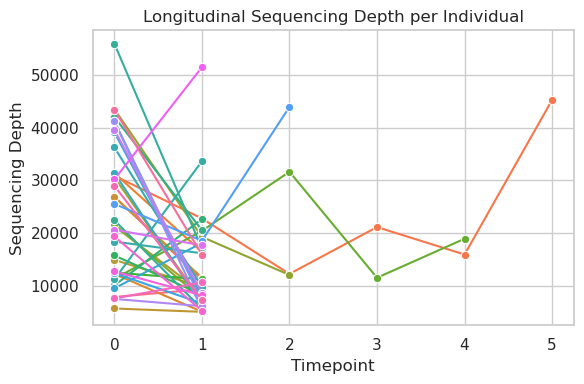

In [29]:
# Sort by person and date, then assign timepoint indices per person
df = final_data.sort_values(["person id", "sequence collection date"])
df["timepoint"] = df.groupby("person id").cumcount()

# Plot: x = num_minor_variants, y = timepoint, line per person
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df,
    x="timepoint",
    y="depth_coverage",
    hue="person id",
    marker="o",
    legend=False  # hide if too many individuals
)

plt.xlabel("Timepoint")
plt.ylabel("Sequencing Depth")
plt.title("Longitudinal Sequencing Depth per Individual")
plt.tight_layout()
plt.show()

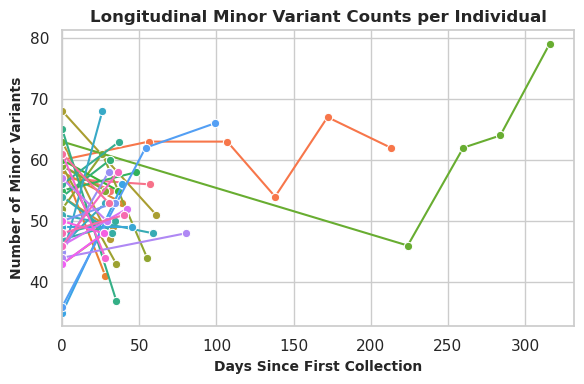

In [30]:
# Sort by person and date
df = final_data.sort_values(["person id", "sequence collection date"])

# Convert to datetime if not already
df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])

# Compute days since the first sample for each person
df["timepoint"] = (
    df.groupby("person id")["sequence collection date"]
      .transform(lambda x: (x - x.min()).dt.days)
)

# Plot with real time spacing
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df,
    x="timepoint",
    y="num_minor_variants",
    hue="person id",
    marker="o",
    legend=False
)

plt.xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
plt.ylabel("Number of Minor Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Minor Variant Counts per Individual", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.xlim(left=0)
plt.show()


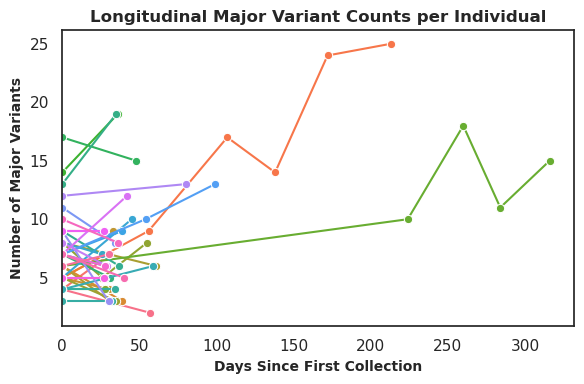

In [31]:
# Sort by person and date
df = final_data.sort_values(["person id", "sequence collection date"])

# Convert to datetime if not already
df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])

# Compute days since the first sample for each person
df["timepoint"] = (
    df.groupby("person id")["sequence collection date"]
      .transform(lambda x: (x - x.min()).dt.days)
)

# Plot with real time spacing
plt.figure(figsize=(6, 4))
sns.set_theme(style='white')
sns.lineplot(
    data=df,
    x="timepoint",
    y="num_major_variants",
    hue="person id",
    marker="o",
    legend=False
)

plt.xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
plt.ylabel("Number of Major Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Major Variant Counts per Individual",fontweight='bold', fontsize=12)
plt.xlim(left=0)
plt.tight_layout()
plt.show()


In [32]:
final_data

,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers,accession,person id,COG-ID,sequence collection date,description
1,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,51,0.9982,36234.4225,58599,978659,902210,ERR10005437,p462,QEUH-3EF7AF8,2022-07-15,Illumina NovaSeq 6000 sequencing: Illumina Nov...
5,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,6,44,0.9891,5241.1467,40314,347488,270287,ERR10023890,p561,QEUH-3F162BE,2022-07-21,Illumina NovaSeq 6000 sequencing: Illumina Nov...
7,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,7,46,0.9985,31379.9072,54877,1065531,2062359,ERR10024128,p467,QEUH-3F17F4D,2022-07-21,Illumina NovaSeq 6000 sequencing: Illumina Nov...
9,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,8,44,0.9972,39110.1332,61095,1059524,2046123,ERR10031773,p469,QEUH-3F2A30F,2022-07-21,Illumina NovaSeq 6000 sequencing: Illumina Nov...
19,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,5,49,0.9982,9489.4236,41130,363802,193673,ERR10080164,p480,QEUH-3F4A98F,2022-08-01,Illumina NovaSeq 6000 sequencing: Illumina Nov...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,/home/project_data/persistent_cov_uk/cleaned_r...,PX447353.1,7,61,0.9981,19337.8147,46310,865888,596455,ERR9908671,p561,QEUH-3E837AF,2022-06-23,Illumina NovaSeq 6000 sequencing: Illumina Nov...
294,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,4,48,0.9986,55930.7125,61240,1490906,3372527,ERR9932102,p431,QEUH-3EA1310,2022-06-28,Illumina NovaSeq 6000 sequencing: Illumina Nov...
297,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,3,54,0.9981,11197.6019,47039,661633,390086,ERR9934506,p444,QEUH-3EB67EF,2022-07-01,Illumina NovaSeq 6000 sequencing: Illumina Nov...
302,/home/project_data/persistent_cov_uk/cleaned_r...,ON249995.1,5,47,0.9983,18364.0476,47285,690444,746538,ERR9967784,p448,QEUH-3ED205B,2022-07-07,Illumina NovaSeq 6000 sequencing: Illumina Nov...


In [33]:
final_data[final_data['person id'] == 'p288'].sort_values(by='sequence collection date')

,filename,selected_genome,num_major_variants,num_minor_variants,breadth_coverage,depth_coverage,num_perfect_kmers,num_variant_kmers,num_unmapped_kmers,accession,person id,COG-ID,sequence collection date,description
217,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,5,60,0.9984,30867.5598,62437,1081984,748366,ERR9753653,p288,QEUH-3CDD474,2022-03-27,Illumina NovaSeq 6000 sequencing: Illumina Nov...
267,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,9,63,0.9983,22758.3613,54911,832567,804078,ERR9824956,p288,QEUH-3E2AB53,2022-05-22,Illumina NovaSeq 6000 sequencing: Illumina Nov...
313,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,17,63,0.9970,12225.7005,43293,523840,374020,ERR9989618,p288,QEUH-3EEE7DF,2022-07-12,Illumina NovaSeq 6000 sequencing: Illumina Nov...
28,/home/project_data/persistent_cov_uk/cleaned_r...,OM354922.1,14,54,0.9957,21115.2009,49709,759447,975861,ERR10119582,p288,QEUH-3F63C1E,2022-08-12,Illumina NovaSeq 6000 sequencing: Illumina Nov...
131,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,24,67,0.9876,15911.1230,49238,510792,435113,ERR13084426,p288,QEUH-32576492,2022-09-15,Illumina NovaSeq 6000 sequencing: Illumina Nov...
64,/home/project_data/persistent_cov_uk/cleaned_r...,PX422652.1,25,62,0.9875,45266.6859,60818,922162,946214,ERR10463466,p288,QEUH-325D74BD,2022-10-26,Illumina NovaSeq 6000 sequencing: Illumina Nov...


In [34]:
final_data['selected_genome'].value_counts()

selected_genome
PX422652.1    31
ON249995.1    27
OZ286419.1     6
OM354922.1     3
PX131797.1     3
OQ329372.1     3
OP661948.1     3
PX447353.1     2
OQ167064.1     2
OP167709.1     2
OL672836.1     2
PV014231.1     1
Name: count, dtype: int64

In [66]:
import os

def heatmap_plot(individual):
    accessions = final_data[(final_data['person id'] == f'p{individual}') & (final_data['accession'] != 'ERR10119582') ].sort_values(by='sequence collection date')['accession'].to_list()  # your list
    vcf_dir = "bronko_results"  # folder containing .vcf files

    records = []

    for acc in accessions:
        vcf_path = os.path.join(vcf_dir, f"{acc}_1.vcf")
        if not os.path.exists(vcf_path):
            continue

        # Read and filter out header lines
        with open(vcf_path) as f:
            lines = [l.strip() for l in f if not l.startswith("#")]

        # Split each variant line by tab into columns
        vcf_df = pd.DataFrame(
            [l.split("\t") for l in lines],
            columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"]
        )
        vcf_df["accession"] = acc
        records.append(vcf_df)

    # Combine all samples
    all_variants = pd.concat(records, ignore_index=True)

    all_variants["AF"] = all_variants["INFO"].str.extract(r"AF=([\d\.eE-]+)").astype(float)
    all_variants["SOR"] = all_variants["INFO"].str.extract(r"SOR=([\d\.eE-]+)").astype(float)
    min_af = 0.01
    max_af = 1.0
    all_variants = all_variants[all_variants["AF"] > min_af]
    all_variants = all_variants[all_variants["SOR"] != 12.0]

    # --- 2. Create variant ID and numeric position ---
    all_variants["POS"] = all_variants["POS"].astype(int)
    all_variants["variant"] = (
        all_variants["CHROM"] + "_" + all_variants["POS"].astype(str) + "_" +
        all_variants["REF"] + ">" + all_variants["ALT"]
    )

    # --- 3. Sort by genome position ---
    all_variants = all_variants.sort_values(["CHROM", "POS"])

    ##--- 4. Pivot table: variants x accessions ---
    heatmap_df = all_variants.pivot_table(
        index="variant",
        columns="accession",
        values="AF",
        fill_value=0
    )
    variant_order = all_variants.drop_duplicates("variant").set_index("variant")["POS"]
    heatmap_df = heatmap_df.loc[variant_order.sort_values().index, accessions]

    # Keep sample order by collection date
    heatmap_df = heatmap_df[accessions]

    # --- 5. Plot ---
    mask = heatmap_df == 0

    # Create figure
    plt.figure(figsize=(6, 7))

    # Draw base gray background
    ax = sns.heatmap(
        heatmap_df,
        cmap="Greys",       # start with gray background
        cbar=False,
        vmin=min_af, vmax=max_af
    )

    # Overlay actual values (nonzero only)
    sns.heatmap(
        heatmap_df,
        cmap="Blues",
        vmin=min_af, vmax=max_af,
        mask=mask,
        cbar_kws={'label': 'Minor Allele Frequency (>5%)'}
    )

    for i in range(heatmap_df.shape[0]):      # rows
        for j in range(heatmap_df.shape[1]):  # columns
            val = heatmap_df.iloc[i, j]
            if val > 0.5:
                ax.text(j + 0.5, i + 0.5, f"{val:.2f}", color="white",
                        ha='center', va='center', fontsize=6)
            elif val > 0.0: 
                ax.text(j + 0.5, i + 0.5, f"{val:.2f}", color="black",
                        ha='center', va='center', fontsize=6)

    plt.xlabel("Sample (ordered by collection date)")
    plt.ylabel("Variant (sorted by genome position)")
    plt.title(f"Variant Allele Over Subsequent Samples — p{individual}")
    plt.tight_layout()
    plt.yticks(
        ticks=np.arange(len(heatmap_df.index)) + 0.5,
        labels=heatmap_df.index,
        fontsize=6      # smaller font
    )
    plt.gca().tick_params(axis='y', labelsize=6)
    plt.show()

In [67]:
final_data["person id"].value_counts()

person id
p288    6
p392    5
p356    3
p493    3
p462    2
p561    2
p444    2
p480    2
p469    2
p467    2
p488    2
p497    2
p498    2
p431    2
p427    2
p407    2
p573    2
p523    2
p532    2
p538    2
p551    2
p448    2
p545    2
p421    2
p574    2
p416    2
p423    2
p339    2
p342    2
p576    2
p343    2
p350    2
p366    2
p286    2
p306    2
p321    2
p192    2
p320    2
Name: count, dtype: int64

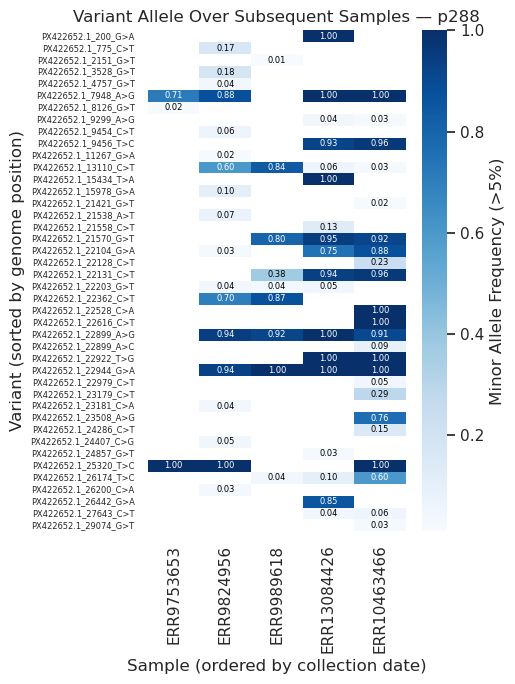

In [68]:
heatmap_plot("288")

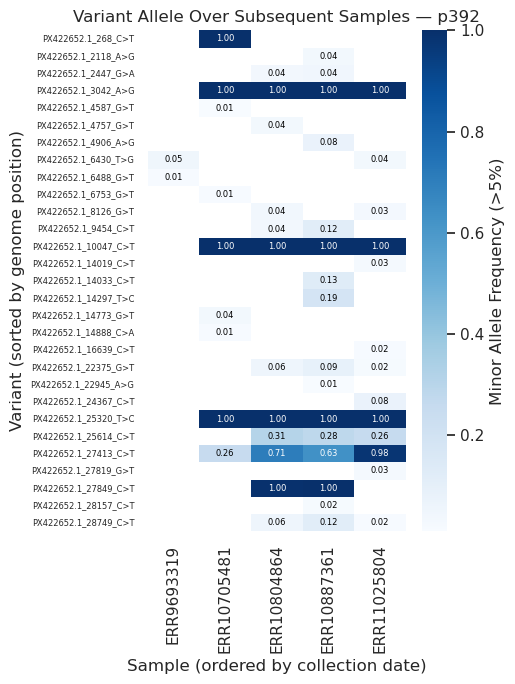

In [69]:
heatmap_plot("392")

In [47]:
heatmap_plot("493")

KeyError: "['ERR10214532'] not in index"

In [48]:
from pathlib import Path

def mutation_spectrum_plot(final_data, vcf_dir="bronko_results", min_af=0.05):
    # Get list of accessions to include
    accessions = final_data["accession"].unique().tolist()
    records = []

    for acc in accessions:
        vcf_path = Path(vcf_dir) / f"{acc}_1.vcf"
        if not vcf_path.exists():
            continue

        # Read and filter out header lines
        with open(vcf_path) as f:
            lines = [l.strip() for l in f if not l.startswith("#")]
        if not lines:
            continue

        # Parse variant table
        df = pd.DataFrame(
            [l.split("\t") for l in lines],
            columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"]
        )
        df["accession"] = acc
        df["AF"] = df["INFO"].str.extract(r"AF=([\d\.eE-]+)").astype(float)
        df = df[df["AF"] > min_af]

        records.append(df[["REF", "ALT", "AF", "accession"]])

    if not records:
        print("No matching VCFs found.")
        return

    all_variants = pd.concat(records, ignore_index=True)

    # Define mutation type
    all_variants["mutation"] = all_variants["REF"] + ">" + all_variants["ALT"]

    # Aggregate by mutation type
    mut_summary = (
        all_variants.groupby("mutation")["AF"]
        .agg(["count", "mean"])
        .reset_index()
        .sort_values("count", ascending=False)
    )

    # --- Plot ---
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(
        data=mut_summary,
        x="mutation", y="count",
        color="steelblue", ax=ax
    )

    ax.set_title("Mutation Spectrum Across Selected Samples", fontsize=12, fontweight='bold')
    ax.set_ylabel("Count of Variants", fontsize=10)
    ax.set_xlabel("Mutation Type", fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    return mut_summary

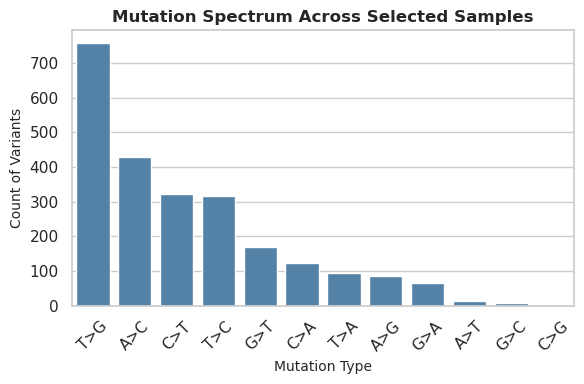

,mutation,count,mean
11,T>G,756,0.146545
0,A>C,428,0.110808
5,C>T,321,0.674259
10,T>C,317,0.585088
8,G>T,168,0.386577
3,C>A,124,0.205685
9,T>A,95,0.616768
1,A>G,84,0.788869
6,G>A,66,0.667652
2,A>T,14,0.364214


In [49]:
mutation_spectrum_plot(final_data)

In [50]:
def mutation_spectrum_af_plot(final_data, vcf_dir="bronko_results", min_af=0.01):
    # 1️⃣ Collect variants for all selected accessions
    accessions = final_data["accession"].unique().tolist()
    records = []

    for acc in accessions:
        vcf_path = Path(vcf_dir) / f"{acc}_1.vcf"
        if not vcf_path.exists():
            continue

        with open(vcf_path) as f:
            lines = [l.strip() for l in f if not l.startswith("#")]
        if not lines:
            continue

        df = pd.DataFrame(
            [l.split("\t") for l in lines],
            columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"]
        )
        df["accession"] = acc
        df["person"] = final_data[final_data['accession'] == acc]['person id'].iloc[0]
        df["AF"] = df["INFO"].str.extract(r"AF=([\d\.eE-]+)").astype(float)
        df["SOR"] = df["INFO"].str.extract(r"SOR=([\d\.eE-]+)").astype(float)
        df = df[df["AF"] > min_af]
        df["mutation"] = df["REF"] + ">" + df["ALT"]

        records.append(df[["mutation", "AF", "accession", "POS", "CHROM", "SOR", "person"]])

    if not records:
        print("No variants found for selected samples.")
        return

    all_variants = pd.concat(records, ignore_index=True)
    all_variants = all_variants[all_variants["SOR"] != 12.0]

    # 2️⃣ Compute counts per mutation type
    mut_counts = (
        all_variants["mutation"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "mutation"})
    )

    # 3️⃣ Sort by count for consistent ordering
    # mut_counts = mut_counts.loc[:, ~mut_counts.columns.duplicated()]

    order = mut_counts.sort_values("count", ascending=False)["mutation"].tolist()

    # 4️⃣ Plot AF distributions per mutation
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(6, 3))

    sns.boxplot(
        data=all_variants,
        x="mutation", y="AF",
        order=order,
        fliersize=0,  # hide outlier markers (we’ll add jitter)
        color="lightgray",
        ax=ax
    )
    sns.stripplot(
        data=all_variants,
        x="mutation", y="AF",
        order=order,
        jitter=True,
        size=3,
        alpha=0.4,
        color="steelblue",
        ax=ax
    )

    # 5️⃣ Add counts above boxes
    counts = all_variants.groupby("mutation")["AF"].count().reindex(order)
    y_max = all_variants["AF"].max()
    for i, (mut, count) in enumerate(counts.items()):
        ax.text(i, y_max + 0.03, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 6️⃣ Style and labels
    ax.set_title("Minor Allele Frequency by Mutation Type", fontsize=12, fontweight='bold')
    ax.set_xlabel("Mutation Type", fontsize=10, fontweight='bold')
    ax.set_ylabel("Minor Allele Frequency", fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    return all_variants

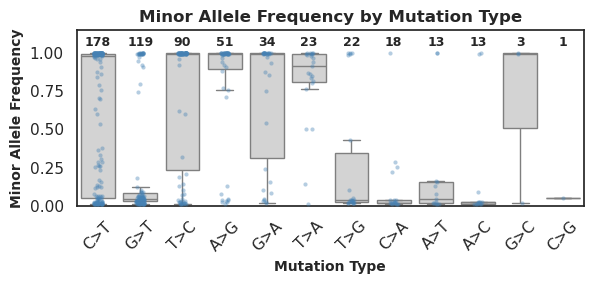

In [51]:
variants = mutation_spectrum_af_plot(final_data, min_af=0.01)

In [72]:
variants

,mutation,AF,accession,POS,CHROM,SOR,person
44,G>A,0.999,ERR10005437,27140,ON249995.1,1.330,p462
46,T>C,0.998,ERR10005437,27364,ON249995.1,4.863,p462
53,C>T,0.994,ERR10005437,29583,ON249995.1,0.017,p462
64,G>T,0.065,ERR10023890,4748,PX447353.1,4.125,p561
75,T>A,0.994,ERR10023890,15425,PX447353.1,0.062,p561
...,...,...,...,...,...,...,...
5188,G>T,0.035,ERR9989618,22203,PX422652.1,1.964,p288
5190,C>T,0.874,ERR9989618,22362,PX422652.1,2.624,p288
5196,A>G,0.922,ERR9989618,22899,PX422652.1,1.486,p288
5197,G>A,1.000,ERR9989618,22944,PX422652.1,1.378,p288


In [180]:
def mutation_spectrum_af_plot_split(final_data, vcf_dir="bronko_results", min_af=0.01):
    # 1️⃣ Collect variants
    accessions = final_data["accession"].unique().tolist()
    records = []

    for acc in accessions:
        vcf_path = Path(vcf_dir) / f"{acc}_1.vcf"
        if not vcf_path.exists():
            continue

        with open(vcf_path) as f:
            lines = [l.strip() for l in f if not l.startswith("#")]
        if not lines:
            continue

        df = pd.DataFrame(
            [l.split("\t") for l in lines],
            columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"]
        )
        df["accession"] = acc
        df["person"] = final_data.loc[final_data["accession"] == acc, "person id"].iloc[0]
        df["AF"] = df["INFO"].str.extract(r"AF=([\d\.eE-]+)").astype(float)
        df["SOR"] = df["INFO"].str.extract(r"SOR=([\d\.eE-]+)").astype(float)
        df = df[df["AF"] > min_af]
        df["mutation"] = df["REF"] + ">" + df["ALT"]

        records.append(df[["mutation", "AF", "accession", "POS", "CHROM", "SOR", "person"]])

    if not records:
        print("No variants found for selected samples.")
        return

    all_variants = pd.concat(records, ignore_index=True)
    all_variants = all_variants[all_variants["SOR"] != 12.0]

    # 2️⃣ Counts per mutation
    mut_counts = (
        all_variants["mutation"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "mutation"})
    )
    order = mut_counts.sort_values("count", ascending=False)["mutation"].tolist()

    # 3️⃣ Plot
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(6, 3))

    sns.boxplot(
        data=all_variants,
        x="mutation", y="AF",
        order=order,
        fliersize=0,
        color="lightgray",
        ax=ax
    )
    sns.stripplot(
        data=all_variants,
        x="mutation", y="AF",
        order=order,
        jitter=True,
        size=3,
        alpha=0.4,
        color="steelblue",
        ax=ax
    )

    # 4️⃣ Horizontal line and labels
    ax.axhline(0.5, color="black", lw=1, linestyle="--", alpha=0.6)
    ax.text(9.7, 0.52, "MAF ≥ 0.5", fontsize=9, fontweight="bold", va="bottom")
    ax.text(9.7, 0.48, "MAF < 0.5", fontsize=9, fontweight="bold", va="top")

    # 5️⃣ Counts above boxes
    major_variants = all_variants[all_variants['AF'] >= 0.5]
    counts = major_variants.groupby("mutation")["AF"].count().reindex(order)
    y_max = major_variants["AF"].max()
    for i, (mut, count) in enumerate(counts.items()):
        if pd.isna(count):
            count = 0
        ax.text(i, y_max + 0.01, str(int(count)), ha="center", va="bottom", fontsize=8, fontweight="bold")
        
    minor_variants = all_variants[all_variants['AF'] < 0.5]
    counts = minor_variants.groupby("mutation")["AF"].count().reindex(order)
    y_max = minor_variants["AF"].max()
    for i, (mut, count) in enumerate(counts.items()):
        ax.text(i, -0.09, str(int(count)), ha="center", va="bottom", fontsize=8, fontweight="bold")

    # 6️⃣ Style
    ax.set_title("Minor Allele Frequency by Mutation Type", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mutation Type", fontsize=10, fontweight="bold")
    ax.set_ylabel("Minor Allele Frequency", fontsize=10, fontweight="bold")
    ax.set_ylim(-0.1, 1.1)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color='black', alpha=0.9, lw=1)
    ax.axhline(1, color='black', alpha=0.9, lw=1)
    plt.tight_layout()
    plt.show()

    return all_variants


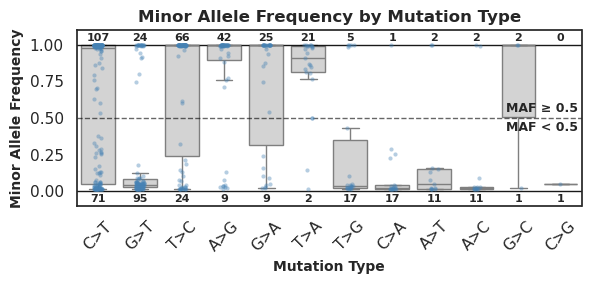

,mutation,AF,accession,POS,CHROM,SOR,person
44,G>A,0.999,ERR10005437,27140,ON249995.1,1.330,p462
46,T>C,0.998,ERR10005437,27364,ON249995.1,4.863,p462
53,C>T,0.994,ERR10005437,29583,ON249995.1,0.017,p462
64,G>T,0.065,ERR10023890,4748,PX447353.1,4.125,p561
75,T>A,0.994,ERR10023890,15425,PX447353.1,0.062,p561
...,...,...,...,...,...,...,...
5188,G>T,0.035,ERR9989618,22203,PX422652.1,1.964,p288
5190,C>T,0.874,ERR9989618,22362,PX422652.1,2.624,p288
5196,A>G,0.922,ERR9989618,22899,PX422652.1,1.486,p288
5197,G>A,1.000,ERR9989618,22944,PX422652.1,1.378,p288


In [181]:
mutation_spectrum_af_plot_split(final_data)

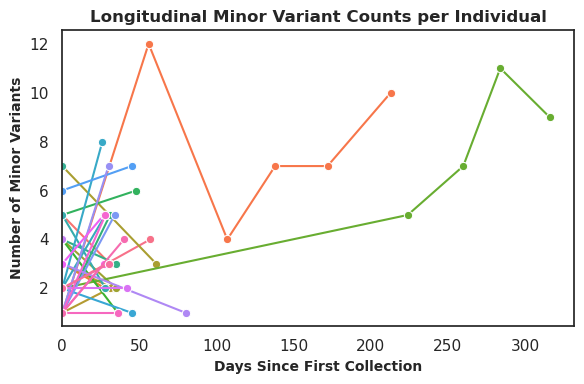

In [186]:
minor_variants = variants[variants['AF'] < 0.5].groupby('accession').count()
minor_variants = minor_variants.merge(final_data, on=['accession'], how="left")
minor_variants['mutation'] = minor_variants['mutation'].fillna(0)

# Sort by person and date
df = minor_variants.sort_values(["person id", "sequence collection date"])

# Convert to datetime if not already
df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])

# Compute days since the first sample for each person
df["timepoint"] = (
    df.groupby("person id")["sequence collection date"]
      .transform(lambda x: (x - x.min()).dt.days)
)

# Plot with real time spacing
plt.figure(figsize=(6, 4))
sns.set_theme(style='white')
sns.lineplot(
    data=df,
    x="timepoint",
    y="mutation",
    hue="person id",
    marker="o",
    legend=False
)

plt.xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
plt.ylabel("Number of Minor Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Minor Variant Counts per Individual",fontweight='bold', fontsize=12)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

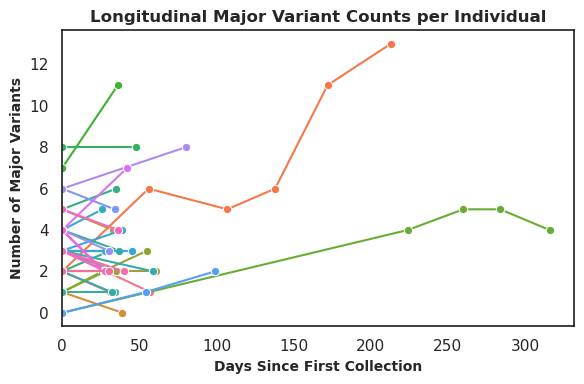

In [187]:
major_variants = variants[variants['AF'] >= 0.5].groupby('accession').count()
major_variants = major_variants.merge(final_data, on=['accession'], how="outer")
major_variants['mutation'] = major_variants['mutation'].fillna(0)
 

# Sort by person and date
df = major_variants.sort_values(["person id", "sequence collection date"])

# Convert to datetime if not already
df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])

# Compute days since the first sample for each person
df["timepoint"] = (
    df.groupby("person id")["sequence collection date"]
      .transform(lambda x: (x - x.min()).dt.days)
)

# Plot with real time spacing
plt.figure(figsize=(6, 4))
sns.set_theme(style='white')
sns.lineplot(
    data=df,
    x="timepoint",
    y="mutation",
    hue="person id",
    marker="o",
    legend=False
)

plt.xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
plt.ylabel("Number of Major Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Major Variant Counts per Individual",fontweight='bold', fontsize=12)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

In [185]:
sum(minor_variants['mutation']) + sum(major_variants['mutation'])

565.0

In [ ]:
# Sort by person and date
df = final_data.sort_values(["person id", "sequence collection date"])

# Convert to datetime if not already
df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])

# Compute days since the first sample for each person
df["timepoint"] = (
    df.groupby("person id")["sequence collection date"]
      .transform(lambda x: (x - x.min()).dt.days)
)

# Plot with real time spacing
plt.figure(figsize=(6, 4))
sns.set_theme(style='white')
sns.lineplot(
    data=df,
    x="timepoint",
    y="num_major_variants",
    hue="person id",
    marker="o",
    legend=False
)

plt.xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
plt.ylabel("Number of Major Variants", fontweight='bold', fontsize=10)
plt.title("Longitudinal Major Variant Counts per Individual",fontweight='bold', fontsize=12)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Number of samples sharing variant')

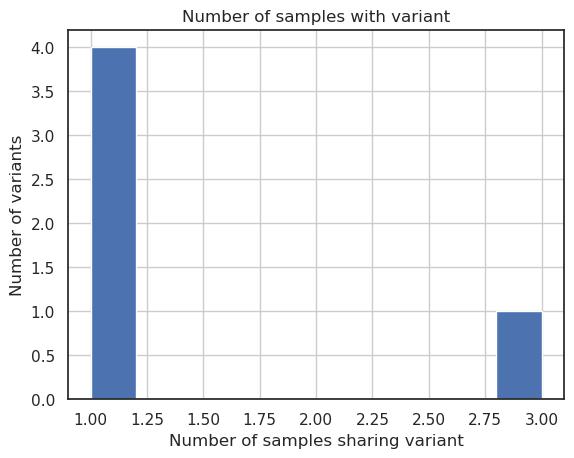

In [53]:
variants[(variants['CHROM'].isin(['ON249995.1'])) & (variants['mutation'] == 'T>G')][['POS', 'CHROM']].value_counts().hist()
plt.title('Number of samples with variant')
plt.ylabel('Number of variants')
plt.xlabel('Number of samples sharing variant')

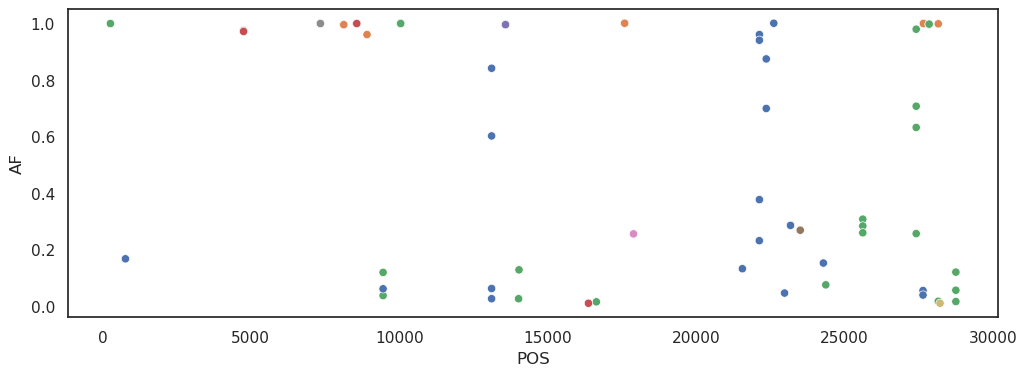

In [57]:
test =variants[(variants['CHROM'].isin(['PX422652.1'])) & (variants['mutation'] == 'C>T')][['POS', 'AF', 'CHROM', 'accession', 'person']]
test['POS'] = test['POS'].astype(int)
plt.figure(figsize=(12, 4))
sns.scatterplot(test, x="POS", y='AF', hue='person')
plt.legend([], [], frameon=False)

In [55]:
variants[variants['mutation'] == 'T>G']['accession'].value_counts()

accession
ERR10481129    3
ERR10475624    2
ERR9934506     2
ERR10088876    1
ERR10463466    1
ERR10481474    1
ERR10512031    1
ERR10667488    1
ERR10769696    1
ERR10481742    1
ERR10777823    1
ERR10804621    1
ERR13084426    1
ERR11025804    1
ERR9693319     1
ERR9758141     1
ERR9760540     1
ERR9824435     1
Name: count, dtype: int64